# How new concepts spread: diffusion types (RQ2 typology demo)

This notebook is a runnable demo of the **RQ2 experiment** "How new concepts spread: types, roles, timing".
The artifact's `method.py` is a thin orchestrator that runs the stages in `src/*.py`:

`prep -> attach -> indicators -> labels -> leiden_seeds -> typology -> roles -> leadlag -> patterns -> validation -> cases -> method_out -> freeze`

Most stages need the full co-word corpus and the iteration-2 yearly network snapshots, which are several GB and are not
shipped here. This notebook runs the central **`typology` stage** (`src/typology.py`) on precomputed per-concept, per-year
indicators for a curated subset of concepts:

* Each concept is a **3-channel yearly series** from its first year `F` to 2024: rarefied Shannon entropy over subfields (`H_rar`),
  Rao–Stirling diversity (`RS`), and the number of active subfields in a 3-year window (`active_subfields_3y`).
* Channels are z-scored. Pairwise distances use **multivariate DTW** (Sakoe–Chiba radius 3), normalised by `sqrt(path length)`.
* Clusters come from **k-medoids** (FasterPAM). The number of clusters `k` is chosen with **Hennig's bootstrap Jaccard stability**:
  the largest k whose minimum cluster Jaccard is above 0.75.
* Baselines: **B1** is an entropy-only DTW typology (the iteration-2 recipe). **B2** is volume only (terciles and a DTW over the volume series).
* The notebook also runs sensitivities, names the clusters from their median breadth trajectories, and cross-tabulates clusters with metadata
  using permutation chi-square tests.

In the full run (202 MAIN concepts), only **k = 2** was stable (min Jaccard 0.861): **localised** (n = 136) vs
**broad from the start** (n = 66). The demo reruns the same code on up to 100 concepts and compares the result with those published labels.

The code is copied from `method.py`, `src/typology.py`, `src/common.py` and `vendor/analysis_patterns.py` with minimal changes.
File reads are replaced by the loaded demo data, and file writes and held-out sealing are dropped.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, sklearn, scipy, matplotlib, numba — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'numba==0.60.0',
         'statsmodels==0.14.6')

# tslearn (DTW), kmedoids (FasterPAM), loguru — NOT on Colab, always install.
# tslearn 0.7.0 is used (the artifact pinned 0.9.0): 0.8.1+ require numba>=0.61 (Colab has 0.60) and 0.8.0 fails to compile under numba 0.60.
_pip('tslearn==0.7.0', 'kmedoids==0.5.5', 'loguru==0.7.3')

In [2]:
# --- original import block of method.py ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

# --- original import block of src/typology.py ---
import math

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

# --- additional imports for the notebook ---
import json
import matplotlib.pyplot as plt

logger.remove()
_ = logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_aMfESsKemlKH/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts in demo file:", len(data["examples"]))

Curated demo subset of the RQ2 diffusion-typology experiment: 100 of the 202 screen MAIN concepts (all 100 are MAIN concepts, stratified 67/33 by the published 3-channel cluster and including both published medoids; held-out concepts are never included). Each concept carries its yearly indicator series (2000-2024) for the channels used by the typology stage (src/typology.py).
concepts in demo file: 100


## Pipeline overview (`method.py`)

`method.py` runs each stage as `python src/<stage>.py`, in the order below. The `run()` helper is shown as in the original.
Here, only the **typology** stage is executed, inline in the cells that follow. The earlier stages (`prep` … `leiden_seeds`)
produced the indicator table that the demo data holds a slice of.

In [5]:
ORDER = ["prep", "attach", "indicators", "labels", "leiden_seeds", "typology", "roles", "leadlag", "patterns", "validation",
         "cases", "method_out", "freeze"]


def run(stage: str, env: dict | None = None) -> float:
    # original orchestrator helper (needs the artifact's src/ folder; not called in this notebook)
    t0 = time.time()
    r = subprocess.run([sys.executable, str(ROOT / "src" / f"{stage}.py")], cwd=ROOT / "src", env=env or os.environ.copy())
    if r.returncode != 0:
        raise SystemExit(f"stage {stage} failed (exit {r.returncode})")
    return time.time() - t0


for i, st in enumerate(ORDER):
    print(f"{i+1:2d}. {st}{'   <-- run inline below' if st == 'typology' else ''}")

 1. prep
 2. attach
 3. indicators
 4. labels
 5. leiden_seeds
 6. typology   <-- run inline below
 7. roles
 8. leadlag
 9. patterns
10. validation
11. cases
12. method_out
13. freeze


## Configuration

These are all the tunable parameters of the typology stage. The **original full-run values** are noted in each comment.
`N_CONCEPTS` caps how many of the 100 demo concepts are used. The full run clustered 202 MAIN concepts, and the ALL_SCREEN_MAINARM sensitivity used 247.

In [6]:
N_CONCEPTS = 100           # concepts taken from the demo file (max 100, all MAIN; original: 247 screen main-arm, 202 MAIN)
K_RANGE = list(range(2, 9))  # candidate k (original: list(range(2, 9)))
B_BOOT = 200               # bootstrap resamples for Hennig Jaccard stability (original: 200)
B_SENS = 100               # bootstrap resamples for sensitivities / residualised variant (original: 100)
JAC_MIN = 0.75             # stability threshold on min cluster Jaccard (original: 0.75)
DTW_RADIUS = 3             # Sakoe-Chiba radius (original: 3)
N_PERM = 10000             # permutations in the cross-tab chi-square tests (original: 10000)
N_PERM_EXPL = 2000         # permutations for exploratory finer-k cross-tabs (original: 2000)
RUN_SENSITIVITIES = True   # run the 7 sensitivity analyses (original: True)

CH = ["H_rar", "RS", "active_subfields_3y"]
CH_RAR = ["H_rar", "RS_rar", "richness_rar"]

# vendored iteration-2 SPEC (vendor/config.py) — only the typology part used by the entropy-only baseline B1
S = dict(typology=dict(ages=list(range(0, 9)), max_missing=3, max_fill=2, sakoe_chiba_radius=2, boot=200, jaccard_min=0.75))

## Rebuild the input tables from the demo data

In the original stage, `typology.py` reads three files:
- `results/indicators/concept_year_indicators_hyd.parquet`: one row per concept and year, called `ind`;
- `work/pool_active.parquet`: the concept pool with fold, arm and population flags, called `pool`;
- `results/labels/groups.csv`: the E_up group and closure tercile, called `grp`.

The demo JSON holds the same columns for the chosen concepts. This cell rebuilds all three tables.
Held-out concepts were excluded when the demo file was built, so the original `load_sealed()` / `assert_not_sealed()` guard is not needed.

In [7]:
concepts = data["examples"][:N_CONCEPTS]
rows = []
for c in concepts:
    s = c["series"]
    for i in range(len(s["year"])):
        rows.append(dict(concept_id=c["concept_id"], F=c["F"], fold=c["fold"], arm=c["arm"],
                         **{k: (np.nan if s[k][i] is None else s[k][i]) for k in s}))
ind = pd.DataFrame(rows)
ind["year"] = ind.year.astype(int)
ind["vol"] = ind.vol.astype(int)
ind["vol3"] = ind.vol3.astype(int)

pool = pd.DataFrame([dict(concept_id=c["concept_id"], phrase=c["phrase"], F=c["F"], fold=c["fold"], arm=c["arm"],
                          MAIN=c["MAIN"], STRICT=c["STRICT"], sense_check_fail=c["sense_check_fail"],
                          iter2_active=c["iter2_active"], origin_group=c["origin_group"], route=c["route"],
                          F_band=c["F_band"]) for c in concepts])
grp = pd.DataFrame([dict(concept_id=c["concept_id"], group=c["E_up_group"], closure_tercile=c["closure_tercile"])
                    for c in concepts]).set_index("concept_id")
published = pd.DataFrame([dict(concept_id=c["concept_id"], published_cluster_name=c["full_run_cluster_name"],
                               published_B1_name=c["full_run_B1_name"]) for c in concepts]).set_index("concept_id")
print("ind:", ind.shape, "| pool:", pool.shape, "| MAIN concepts:", int(pool.MAIN.sum()))
ind.head()

ind: (1669, 14) | pool: (100, 12) | MAIN concepts: 100


,concept_id,F,fold,arm,year,age,vol,vol3,H,H_rar,RS,RS_rar,richness_rar,active_subfields_3y
0,c_007a7950eb4d,2007,screen,main,2005,-2.0,0,0,NaN,NaN,NaN,NaN,NaN,0
1,c_007a7950eb4d,2007,screen,main,2006,-1.0,0,0,NaN,NaN,NaN,NaN,NaN,0
2,c_007a7950eb4d,2007,screen,main,2007,0.0,7,7,0.796312,NaN,0.367381,NaN,NaN,1
3,c_007a7950eb4d,2007,screen,main,2008,1.0,8,15,1.169993,1.042326,0.468488,0.455581,3.90,2
4,c_007a7950eb4d,2007,screen,main,2009,2.0,11,26,1.313167,1.161969,0.515243,0.475689,3.92,2


## Series construction and multivariate DTW distances

These functions are copied from `src/typology.py`:
- `build_series` builds one raw (unscaled) multichannel series per concept, from year `F` to 2024. It applies the declared
  missing-value rule: when `H_rar` is NaN because the 3-year volume is under 10 papers, the raw `H` of the same window is used,
  and any remaining NaN becomes 0.
- `zscale` z-scores each channel over all concept-years.
- `dtw_norm` / `dist_matrix` compute Sakoe–Chiba constrained multivariate DTW, divided by `sqrt(len(path))`,
  so that concepts with longer series are not penalised.

In [8]:
def build_series(ind: pd.DataFrame, ids: list[str], channels: list[str], ages: list[int] | None = None,
                 impute: bool = True) -> tuple[dict, pd.DataFrame]:
    """Per-concept raw (unscaled) multichannel series and the per-concept imputed share.

    Declared missing rule: H_rar NaN (vol3 < 10) -> raw H of the same window (imputed); if vol3 == 0 -> H = RS = 0 and
    count = 0 (imputed if the value was NaN); any other NaN (e.g. all window papers without a known subfield) -> 0
    (imputed). No concept is excluded.
    """
    ser, imp = {}, []
    sub = ind[ind.concept_id.isin(set(ids))]
    for c, g in sub.groupby("concept_id"):
        F = int(g.F.iloc[0])
        g = g[(g.year >= F) & (g.year <= 2024)].sort_values("year")
        if ages is not None:
            g = g[g.age.isin(ages)]
        X = np.zeros((len(g), len(channels)))
        n_imp = np.zeros(len(g), dtype=bool)
        for j, ch in enumerate(channels):
            v = g[ch].astype(float).values.copy()
            if ch == "H_rar":
                fb = np.isnan(v)
                v[fb] = g.H.astype(float).values[fb]
                n_imp |= fb
            nan = np.isnan(v)
            n_imp |= nan
            v[nan] = 0.0
            X[:, j] = v
        ser[c] = X
        imp.append(dict(concept_id=c, n_years=len(g), imputed_share=float(n_imp.mean()) if len(g) else np.nan))
    return ser, pd.DataFrame(imp)


def zscale(ser: dict) -> tuple[dict, dict]:
    allv = np.vstack(list(ser.values()))
    mu, sd = allv.mean(axis=0), allv.std(axis=0)
    sd[sd == 0] = 1.0
    return {c: (X - mu) / sd for c, X in ser.items()}, dict(mean=mu.tolist(), sd=sd.tolist())


def dtw_norm(a: np.ndarray, b: np.ndarray, radius: int = DTW_RADIUS, normalise: bool = True) -> float:
    from tslearn.metrics import dtw_path
    path, d = dtw_path(a, b, global_constraint="sakoe_chiba", sakoe_chiba_radius=radius)
    return float(d / math.sqrt(len(path))) if normalise else float(d)


def dist_matrix(ser: dict, ids: list[str], radius: int = DTW_RADIUS, normalise: bool = True) -> np.ndarray:
    n = len(ids)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = dtw_norm(ser[ids[i]], ser[ids[j]], radius, normalise)
    return D

## Clustering helpers (vendored from `vendor/analysis_patterns.py`)

- `_cluster` runs k-medoids (FasterPAM) on a precomputed distance matrix.
- `_stability` is Hennig's bootstrap stability. On each resample it re-clusters the concepts and, for every original cluster,
  records the best Jaccard overlap with a resample cluster. The mean over resamples gives one Jaccard value per cluster.
- `_series_tensor` builds the iteration-2 entropy-only input: raw `H` at ages 0–8, with a short forward/backward fill.
  It is used by baseline B1.

In [9]:
def _series_tensor(ind: pd.DataFrame, channels: list[str]) -> tuple[np.ndarray, list[str], int]:
    T = S["typology"]
    scr = ind[(ind.fold == "screen")].copy()
    for ch in channels:
        v = scr[ch].astype(float)
        scr[ch] = (v - v.mean()) / v.std()
    ages = T["ages"]
    X, ids, dropped = [], [], 0
    for c, g in scr.groupby("concept_id"):
        g = g.set_index("age").reindex(ages)[channels]
        missing = g.isna().any(axis=1).sum()
        if missing > T["max_missing"]:
            dropped += 1
            continue
        g = g.ffill(limit=T["max_fill"]).bfill(limit=T["max_fill"]).fillna(0.0)
        X.append(g.values)
        ids.append(c)
    return np.array(X), ids, dropped


def _cluster(D: np.ndarray, k: int, seed: int = 0) -> np.ndarray:
    import kmedoids
    # .astype(np.int64): notebook fix - kmedoids returns uint64 labels, which np.bincount rejects under Colab's numpy 2.0.2
    return np.asarray(kmedoids.fasterpam(D, k, random_state=seed).labels).astype(np.int64)


def _stability(D: np.ndarray, labels: np.ndarray, k: int, B: int, seed: int = 0) -> list[float]:
    rng = np.random.default_rng(seed)
    n = len(D)
    jac = np.zeros((B, k))
    for b in range(B):
        idx = np.unique(rng.integers(0, n, n))
        if len(idx) <= k:
            continue
        lb = _cluster(D[np.ix_(idx, idx)], k, seed=b)
        for ci in range(k):
            A = set(idx[labels[idx] == ci])
            best = 0.0
            for cb in range(k):
                Bs = set(idx[lb == cb])
                u = len(A | Bs)
                if u:
                    best = max(best, len(A & Bs) / u)
            jac[b, ci] = best
    return jac.mean(axis=0).tolist()

## k selection, AMI, and the stability bands (`src/typology.py`)

`select_k` clusters the concepts at every k in `K_RANGE` and records per-cluster bootstrap Jaccards, the silhouette and the medoids.
It picks the **largest k whose minimum Jaccard is above `JAC_MIN`**. Among stable k in the same Jaccard band, the higher silhouette wins the tie.
`hennig_band` maps a Jaccard value to Hennig's verbal bands: stable, pattern, weak and dissolved.

In [10]:
def select_k(D: np.ndarray, k_range=K_RANGE, B: int = B_BOOT) -> dict:
    import kmedoids
    res = {}
    for k in k_range:
        if k >= len(D):
            continue
        lb = _cluster(D, k)
        st = _stability(D, lb, k, B, seed=k)
        sil = float(silhouette_score(D, lb, metric="precomputed")) if len(set(lb)) > 1 else np.nan
        med = kmedoids.fasterpam(D, k, random_state=0).medoids
        res[k] = dict(labels=lb, jaccard=st, min_jaccard=float(min(st)), silhouette=sil,
                      sizes=np.bincount(lb, minlength=k).tolist(), medoids=[int(m) for m in med])
    stable = [k for k in res if res[k]["min_jaccard"] > JAC_MIN]
    if stable:
        top = max(stable)
        # tie-break: among stable k in the same min-Jaccard band (within 0.02 of each other) prefer higher silhouette
        band = [k for k in stable if abs(res[k]["min_jaccard"] - res[top]["min_jaccard"]) < 0.02 and k >= top - 1]
        k_sel = max(band, key=lambda k: (res[k]["silhouette"], k))
        status = "stable"
    else:
        k_sel = max(res, key=lambda k: (res[k]["min_jaccard"], res[k]["silhouette"]))
        status = "no stable typology"
    return dict(by_k=res, k_sel=k_sel, status=status, stable_ks=stable)


def hennig_band(j: float) -> str:
    return "stable" if j > 0.75 else ("pattern" if j >= 0.6 else ("weak" if j > 0.5 else "dissolved"))


def ami(a: pd.Series, b: pd.Series) -> float:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    return float(adjusted_mutual_info_score(m.a.astype(str), m.b.astype(str))) if len(m) > 5 else np.nan

## Baseline B1 (entropy only) and the permutation chi-square test

- `entropy_only` is the iteration-2 recipe. It uses raw `H` only, at ages 0–8, with `cdist_dtw` (radius 2) and FasterPAM.
  With `k=None`, k is chosen by the same stability rule as the primary typology.
- `perm_chi2` gives a chi-square statistic with a permutation p-value, Cramér's V and standardised residuals.
  It is used for the cluster × metadata cross-tabs.

In [11]:
def entropy_only(ind: pd.DataFrame, ids: list[str], k: int | None, B: int = B_BOOT, seed: int = 99) -> dict:
    """B1: the iteration-2 entropy-only recipe (analysis_patterns._series_tensor on raw H, ages 0..8, z-scored over the
    given screen concepts, cdist_dtw radius 2, fasterpam). k=None -> k selected by the same stability rule."""
    from tslearn.metrics import cdist_dtw
    sub = ind[ind.concept_id.isin(set(ids))].copy()
    sub["fold"] = "screen"
    X, idh, dropped = _series_tensor(sub, ["H"])
    Dh = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=2)
    if k is None:
        sel = select_k(Dh, B=B)
        k = sel["k_sel"]
        lb = sel["by_k"][k]["labels"]
        st = sel["by_k"][k]["jaccard"]
        table = {str(kk): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], silhouette=v["silhouette"], sizes=v["sizes"])
                 for kk, v in sel["by_k"].items()}
        status = sel["status"]
    else:
        lb = _cluster(Dh, k)
        st = _stability(Dh, lb, k, B, seed=seed)
        table, status = None, None
    return dict(ids=idh, labels=np.asarray(lb), k=k, jaccard=st, min_jaccard=float(min(st)), n=len(idh),
                n_dropped_missing=dropped, table=table, status=status, D=Dh)


def perm_chi2(a: pd.Series, b: pd.Series, n_perm: int = N_PERM, seed: int = 0) -> dict:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    ai = pd.factorize(m.a.astype(str), sort=True)
    bi = pd.factorize(m.b.astype(str), sort=True)
    ka, kb, n = len(ai[1]), len(bi[1]), len(m)
    if ka < 2 or kb < 2:
        return dict(n=n, chi2=np.nan, p_perm=np.nan)

    def chi2(x, y):
        tab = np.bincount(x * kb + y, minlength=ka * kb).reshape(ka, kb).astype(float)
        e = tab.sum(1, keepdims=True) * tab.sum(0, keepdims=True) / n
        return float(((tab - e) ** 2 / np.where(e > 0, e, 1)).sum()), tab, e

    obs, tab, e = chi2(ai[0], bi[0])
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        if chi2(ai[0], rng.permutation(bi[0]))[0] >= obs - 1e-12:
            ge += 1
    rs = (tab - e) / np.sqrt(np.where(e > 0, e, 1) * (1 - tab.sum(1, keepdims=True) / n) * (1 - tab.sum(0, keepdims=True) / n))
    V = math.sqrt(obs / (n * (min(ka, kb) - 1)))
    return dict(n=n, chi2=obs, p_perm=(ge + 1) / (n_perm + 1), cramers_v=V, rows=list(ai[1]), cols=list(bi[1]),
                table=tab.astype(int).tolist(), std_residuals=np.round(rs, 3).tolist(), min_expected=float(e.min()))

## Cluster description and naming (`src/typology.py`)

Clusters are named **after** clustering, from the median trajectory of `active_subfields_3y` by concept age. The rule is fixed in advance:
1. The cluster with the lowest final level is **localised**.
2. The cluster with the highest start level is **broad from the start**, if that level is at or above the median start.
3. Of the rest, a cluster that ends at least 30% below its peak is **temporary expansion**. One with a positive slope is **gradual broadening**. Otherwise it is **stable intermediate**.

In [12]:
def describe(ser_raw: dict, ind: pd.DataFrame, asg: pd.DataFrame, channels: list[str]) -> tuple[pd.DataFrame, dict]:
    rows = []
    for c, X in ser_raw.items():
        cl = asg.loc[asg.concept_id == c, "cluster"]
        if cl.empty:
            continue
        for a in range(len(X)):
            rows.append(dict(concept_id=c, cluster=int(cl.iloc[0]), age=a, **{ch: X[a, j] for j, ch in enumerate(channels)}))
    long = pd.DataFrame(rows)
    traj = long.groupby(["cluster", "age"]).agg(n=("concept_id", "size"),
                                                **{f"{ch}_{q}": (ch, (lambda v, q=q: np.quantile(v, q))) for ch in channels
                                                   for q in (0.25, 0.5, 0.75)}).reset_index()
    desc = {}
    for cl, g in traj.groupby("cluster"):
        g = g[g.n >= 5]
        d = {}
        for ch in channels:
            med = g[f"{ch}_0.5"].values
            d[ch] = dict(start=float(med[:2].mean()), final=float(med[-3:].mean()), peak=float(med.max()),
                         peak_age=int(g.age.values[int(np.argmax(med))]), slope=float(np.polyfit(g.age.values, med, 1)[0]),
                         drop_from_peak=float(med.max() - med[-3:].mean()))
        desc[int(cl)] = d
    return traj, desc


def name_clusters(desc: dict, sizes: dict, ch_key: str = "active_subfields_3y") -> tuple[dict, str]:
    """Name clusters AFTER clustering from the median breadth trajectory (declared rule, numbers written out)."""
    cl = sorted(desc)
    fin = {c: desc[c][ch_key]["final"] for c in cl}
    start = {c: desc[c][ch_key]["start"] for c in cl}
    drop = {c: desc[c][ch_key]["drop_from_peak"] / max(desc[c][ch_key]["peak"], 1e-9) for c in cl}
    slope = {c: desc[c][ch_key]["slope"] for c in cl}
    names = {}
    lo = min(cl, key=lambda c: fin[c])
    names[lo] = "localised"
    rest = [c for c in cl if c not in names]
    if rest:
        hs = max(rest, key=lambda c: start[c])
        if start[hs] >= np.median(list(start.values())) and start[hs] > start[lo]:
            names[hs] = "broad from the start (rapid interdisciplinary)"
    for c in cl:
        if c in names:
            continue
        if drop[c] >= 0.30:
            names[c] = "temporary expansion"
        elif slope[c] > 0:
            names[c] = "gradual broadening"
        else:
            names[c] = "stable intermediate"
    seen: dict = {}
    for c in cl:
        seen[names[c]] = seen.get(names[c], 0) + 1
    for c in cl:
        if seen[names[c]] > 1:
            rank = sorted([x for x in cl if names[x] == names[c]], key=lambda x: fin[x]).index(c) + 1
            names[c] = f"{names[c]} ({'narrower' if rank == 1 else 'broader'}{'' if rank <= 2 else ' ' + str(rank)})"
    lines = ["# Typology naming rule (applied after clustering)", "",
             f"Names come from the median trajectory of `{ch_key}` (number of subfields with >= 2 c-papers in the 3-year window)",
             "by concept age, computed per cluster over ages with >= 5 concepts:", "",
             "1. the cluster with the lowest final level (mean of the last 3 median ages) = **localised**;",
             "2. of the rest, the cluster with the highest start level (mean of ages 0-1), if >= the median start and above",
             "   the localised start = **broad from the start (rapid interdisciplinary)**;",
             "3. any other cluster whose final level is >= 30% below its peak = **temporary expansion**;",
             "4. else positive OLS slope over age = **gradual broadening**; else **stable intermediate**;",
             "5. duplicates are suffixed narrower/broader by final level.", "",
             "| cluster | n | start | peak (age) | final | slope/yr | drop from peak | name |", "|---|---|---|---|---|---|---|---|"]
    for c in cl:
        d = desc[c][ch_key]
        lines.append(f"| {c} | {sizes.get(c, '')} | {d['start']:.2f} | {d['peak']:.2f} ({d['peak_age']}) | {d['final']:.2f} | "
                     f"{d['slope']:.3f} | {drop[c]:.2f} | {names[c]} |")
    return names, "\n".join(lines) + "\n"

## Step 1: build the 3-channel series, the DTW distance matrix, and select k

This is the start of `typology.main()`. The populations are defined as in the original: **MAIN** is primary, and **STRICT**, **ALL_SCREEN_MAINARM** and
**MAIN_no_sense_fail** are sensitivities. The MAIN series are z-scored, the pairwise normalised DTW matrix `D` is built, and k is chosen by bootstrap stability.

In [13]:
t_start = time.time()
scr = pool[(pool.fold == "screen") & (pool.arm == "main")]
pops = {"MAIN": sorted(scr.loc[scr.MAIN, "concept_id"]), "STRICT": sorted(scr.loc[scr.STRICT, "concept_id"]),
        "ALL_SCREEN_MAINARM": sorted(scr.concept_id),
        "MAIN_no_sense_fail": sorted(scr.loc[scr.MAIN & ~scr.sense_check_fail, "concept_id"])}
ids = pops["MAIN"]
out: dict = dict(population="screen MAIN", n=len(ids), channels=CH, dtw=dict(radius=DTW_RADIUS, normalisation="dtw/sqrt(len(path))",
                 constraint="sakoe_chiba"), k_range=K_RANGE, B=B_BOOT, jaccard_min=JAC_MIN)
ser_raw, imp = build_series(ind, ids, CH)
out["imputation"] = dict(concept_year_imputed_share=float(np.average(imp.imputed_share, weights=imp.n_years)),
                         median_concept_share=float(imp.imputed_share.median()), n_excluded=0,
                         series_length_range=[int(imp.n_years.min()), int(imp.n_years.max())])
ser, scaling = zscale(ser_raw)
D = dist_matrix(ser, ids)
sel = select_k(D)
k = sel["k_sel"]
out["status"] = sel["status"]
out["stable_ks"] = sel["stable_ks"]
out["k_selected"] = k
out["by_k"] = {str(kk): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], silhouette=v["silhouette"],
                             sizes=v["sizes"], hennig_band_min=hennig_band(v["min_jaccard"]))
               for kk, v in sel["by_k"].items()}
logger.info(f"3-channel typology: status={sel['status']} k={k}; min Jaccard by k "
            f"{ {kk: round(v['min_jaccard'], 3) for kk, v in sel['by_k'].items()} }")
lab3 = sel["by_k"][k]["labels"]
print("populations:", {p: len(v) for p, v in pops.items()}, "| imputation:", out["imputation"])

03:48:21|INFO   |3-channel typology: status=stable k=2; min Jaccard by k {2: 0.923, 3: 0.738, 4: 0.716, 5: 0.615, 6: 0.517, 7: 0.549, 8: 0.505}


populations: {'MAIN': 100, 'STRICT': 98, 'ALL_SCREEN_MAINARM': 100, 'MAIN_no_sense_fail': 100} | imputation: {'concept_year_imputed_share': 0.12389380530973451, 'median_concept_share': 0.058823529411764705, 'n_excluded': 0, 'series_length_range': [9, 20]}


## Step 2: baseline B1 (entropy only)

The original first reproduces iteration 2 on the 123 older concepts. That check needs the iteration-2 label files, which are not
included here, so it is skipped. Then the entropy-only baseline runs on the MAIN concepts twice: once with its own stability-selected k, and once fixed at the primary k.

In [14]:
b1 = entropy_only(ind, ids, k=None)
out["B1_entropy_only_MAIN"] = dict(n=b1["n"], n_dropped_missing=b1["n_dropped_missing"], k=b1["k"], status=b1["status"],
                                   min_jaccard=b1["min_jaccard"], by_k=b1["table"])
b1_fixed = entropy_only(ind, ids, k=k)
out["B1_entropy_only_MAIN_at_kstar"] = dict(k=k, min_jaccard=b1_fixed["min_jaccard"], jaccard=b1_fixed["jaccard"])
print("B1 (own k):", {kk: v for kk, v in out["B1_entropy_only_MAIN"].items() if kk != "by_k"})
print("B1 at k*:", out["B1_entropy_only_MAIN_at_kstar"])

B1 (own k): {'n': 99, 'n_dropped_missing': 1, 'k': 2, 'status': 'stable', 'min_jaccard': 0.7747622228574724}
B1 at k*: {'k': 2, 'min_jaccard': 0.7847980253911279, 'jaccard': [0.8524828471931145, 0.7847980253911279]}


## Step 3: baseline B2 (volume only) and the "volume-driven" check

Is the typology just a proxy for how many papers a concept has? B2 uses (a) terciles of log cumulative volume and
(b) a DTW typology on the log-volume series. The typology is flagged as volume-driven if AMI(3-channel, volume terciles) > 0.5,
or if the rank correlation between clusters and volume is above 0.6 in absolute value.

In [15]:
cumv = {c: float(ind[(ind.concept_id == c) & (ind.year >= int(ind.loc[ind.concept_id == c, "F"].iloc[0]))].vol.sum()) for c in ids}
logv = pd.Series({c: math.log1p(v) for c, v in cumv.items()})
terc = pd.qcut(logv.rank(method="first"), 3, labels=["V1_low", "V2_mid", "V3_high"])
vser = {}
for c in ids:
    g = ind[(ind.concept_id == c)].sort_values("year")
    g = g[g.year >= int(g.F.iloc[0])]
    vser[c] = np.log1p(g.vol.values.astype(float))[:, None]
vz, _ = zscale(vser)
Dv = dist_matrix(vz, ids)
lbv = _cluster(Dv, k)
asg = pd.DataFrame(dict(concept_id=ids, cluster=lab3))
asg["cluster_B1"] = asg.concept_id.map(dict(zip(b1["ids"], b1["labels"])))
asg["cluster_B1_kstar"] = asg.concept_id.map(dict(zip(b1_fixed["ids"], b1_fixed["labels"])))
asg["B2_vol_tercile"] = asg.concept_id.map(terc.astype(str))
asg["cluster_B2_volseries"] = lbv
asg["log_cum_vol"] = asg.concept_id.map(logv)
rho = spearmanr(asg.cluster, asg.log_cum_vol).statistic
# cluster-level volume association (rank of cluster by median volume vs volume)
med_rank = asg.groupby("cluster").log_cum_vol.median().rank().to_dict()
rho_ord = spearmanr(asg.cluster.map(med_rank), asg.log_cum_vol).statistic
out["baselines"] = dict(
    AMI_3ch_vs_B1=ami(asg.cluster, asg.cluster_B1), AMI_3ch_vs_B1_kstar=ami(asg.cluster, asg.cluster_B1_kstar),
    AMI_3ch_vs_B2_tercile=ami(asg.cluster, asg.B2_vol_tercile), AMI_3ch_vs_B2_volseries=ami(asg.cluster, asg.cluster_B2_volseries),
    B2_volseries_min_jaccard=float(min(_stability(Dv, lbv, k, B_BOOT, seed=7))),
    spearman_cluster_code_vs_logcumvol=float(rho), spearman_cluster_volrank_vs_logcumvol=float(rho_ord))
vol_driven = bool(out["baselines"]["AMI_3ch_vs_B2_tercile"] > 0.5 or abs(rho_ord) > 0.6)
out["volume_driven_flag"] = dict(rule="AMI(3ch, volume terciles) > 0.5 or |Spearman(cluster volume rank, log cum vol)| > 0.6",
                                 flag=vol_driven)
print(json.dumps(out["baselines"], indent=1))
print("volume-driven:", vol_driven)

{
 "AMI_3ch_vs_B1": 0.45681901676008463,
 "AMI_3ch_vs_B1_kstar": 0.45681901676008463,
 "AMI_3ch_vs_B2_tercile": 0.023008098158073035,
 "AMI_3ch_vs_B2_volseries": 0.056830754202077,
 "B2_volseries_min_jaccard": 0.9333243786614535,
 "spearman_cluster_code_vs_logcumvol": 0.2626360484753572,
 "spearman_cluster_volrank_vs_logcumvol": 0.2626360484753572
}
volume-driven: False


## Step 4: volume-residualised variant (secondary)

Before z-scoring, each channel is residualised on `log1p(vol3)` and on age, using OLS. The typology is then re-derived.

In [16]:
rr = ind[ind.concept_id.isin(ids) & (ind.year >= ind.F)].copy()
rr["H_rar"] = rr.H_rar.fillna(rr.H).fillna(0.0)
rr["RS"] = rr.RS.fillna(0.0)
Xr = np.column_stack([np.ones(len(rr)), np.log1p(rr.vol3), rr.age])
for ch in CH:
    beta, *_ = np.linalg.lstsq(Xr, rr[ch].astype(float).values, rcond=None)
    rr[ch] = rr[ch].astype(float).values - Xr @ beta
ser_res = {c: g.sort_values("year")[CH].values for c, g in rr.groupby("concept_id")}
ser_res, _ = zscale(ser_res)
Dres = dist_matrix(ser_res, ids)
sel_res = select_k(Dres, B=B_SENS)
asg["cluster_volres"] = sel_res["by_k"][sel_res["k_sel"]]["labels"]
out["volume_residualised_variant"] = dict(k=sel_res["k_sel"], status=sel_res["status"],
                                          min_jaccard=sel_res["by_k"][sel_res["k_sel"]]["min_jaccard"],
                                          by_k={str(kk): v["min_jaccard"] for kk, v in sel_res["by_k"].items()},
                                          AMI_vs_primary=ami(asg.cluster, asg.cluster_volres),
                                          AMI_vs_B2_tercile=ami(asg.cluster_volres, asg.B2_vol_tercile))
print(out["volume_residualised_variant"])

{'k': 2, 'status': 'stable', 'min_jaccard': 0.8779680393659227, 'by_k': {'2': 0.8779680393659227, '3': 0.5008799802278905, '4': 0.6182280220893055, '5': 0.5356547469251209, '6': 0.546634589017145, '7': 0.5408452380952382, '8': 0.46520114607614604}, 'AMI_vs_primary': 0.6434275371429402, 'AMI_vs_B2_tercile': 0.005207510875012504}


## Step 5: sensitivities

With k fixed at k*, the typology is re-derived under alternatives: rarefied channels, ages 0–8 only, unnormalised DTW, radius 2,
and the STRICT, all-main-arm and no-sense-fail populations. Each alternative gets its min Jaccard and its AMI with the primary labels on shared concepts.

In [17]:
sens = {}

def run_sens(name, s_ids, channels=CH, ages=None, radius=DTW_RADIUS, normalise=True):
    sr, _ = build_series(ind, s_ids, channels, ages=ages)
    sz, _ = zscale(sr)
    Ds = dist_matrix(sz, s_ids, radius, normalise)
    lb = _cluster(Ds, k)
    st = _stability(Ds, lb, k, B_SENS, seed=k)
    a = ami(asg.set_index("concept_id").cluster, pd.Series(lb, index=s_ids))
    sens[name] = dict(n=len(s_ids), k=k, min_jaccard=float(min(st)), AMI_vs_primary=a, sizes=np.bincount(lb).tolist())
    logger.info(f"sensitivity {name}: {sens[name]}")

if RUN_SENSITIVITIES:
    run_sens("rarefied_channels", ids, channels=CH_RAR)
    run_sens("ages_0_8", ids, ages=list(range(0, 9)))
    run_sens("raw_dtw_unnormalised", ids, normalise=False)
    run_sens("radius_2", ids, radius=2)
    run_sens("STRICT", pops["STRICT"])
    run_sens("ALL_SCREEN_MAINARM", pops["ALL_SCREEN_MAINARM"])
    run_sens("MAIN_no_sense_fail", pops["MAIN_no_sense_fail"])
out["sensitivities"] = sens
# ---- all-main-arm assignments for the sensitivity dataset (same k)
sr, _ = build_series(ind, pops["ALL_SCREEN_MAINARM"], CH)
sz, _ = zscale(sr)
Dall = dist_matrix(sz, pops["ALL_SCREEN_MAINARM"])
asg_all = pd.DataFrame(dict(concept_id=pops["ALL_SCREEN_MAINARM"], cluster=_cluster(Dall, k)))

03:48:25|INFO   |sensitivity rarefied_channels: {'n': 100, 'k': 2, 'min_jaccard': 0.8266682702466014, 'AMI_vs_primary': 0.6829914296983441, 'sizes': [77, 23]}


03:48:26|INFO   |sensitivity ages_0_8: {'n': 100, 'k': 2, 'min_jaccard': 0.8337221555958011, 'AMI_vs_primary': 0.780674377425857, 'sizes': [28, 72]}


03:48:26|INFO   |sensitivity raw_dtw_unnormalised: {'n': 100, 'k': 2, 'min_jaccard': 0.9642664747682582, 'AMI_vs_primary': 0.919851417195381, 'sizes': [70, 30]}


03:48:27|INFO   |sensitivity radius_2: {'n': 100, 'k': 2, 'min_jaccard': 0.9251113795493925, 'AMI_vs_primary': 1.0, 'sizes': [71, 29]}


03:48:28|INFO   |sensitivity STRICT: {'n': 98, 'k': 2, 'min_jaccard': 0.9196407155254065, 'AMI_vs_primary': 1.0, 'sizes': [70, 28]}


03:48:29|INFO   |sensitivity ALL_SCREEN_MAINARM: {'n': 100, 'k': 2, 'min_jaccard': 0.9266245451651288, 'AMI_vs_primary': 1.0, 'sizes': [71, 29]}


03:48:29|INFO   |sensitivity MAIN_no_sense_fail: {'n': 100, 'k': 2, 'min_jaccard': 0.9266245451651288, 'AMI_vs_primary': 1.0, 'sizes': [71, 29]}


## Step 6: describe and name the clusters, and name the B1 clusters

In [18]:
traj, desc = describe(ser_raw, ind, asg, CH)
sizes = asg.cluster.value_counts().to_dict()
names, md = name_clusters(desc, sizes)
asg["cluster_name"] = asg.cluster.map(names)
out["cluster_names"] = {str(c): n for c, n in names.items()}
out["cluster_description"] = desc
out["cluster_sizes"] = {str(c): int(v) for c, v in sizes.items()}
out["interpretable_clusters"] = {str(c): bool(v >= 10) for c, v in sizes.items()}
# B1 naming (so predict_baseline carries a readable label)
serH, _ = build_series(ind, b1["ids"], ["H"], ages=list(range(0, 9)))
b1asg = pd.DataFrame(dict(concept_id=b1["ids"], cluster=b1["labels"]))
medH = {c: float(np.median([serH[x][:, 0].mean() for x in b1asg.concept_id[b1asg.cluster == c]])) for c in sorted(set(b1["labels"]))}
order = sorted(medH, key=medH.get)
b1names = {c: f"entropy-{'low' if i == 0 else ('high' if i == len(order) - 1 else 'mid' + str(i))} (H median {medH[c]:.2f})"
           for i, c in enumerate(order)}
asg["cluster_B1_name"] = asg.cluster_B1.map(b1names)
out["B1_names"] = {str(c): v for c, v in b1names.items()}
print(md)

# Typology naming rule (applied after clustering)

Names come from the median trajectory of `active_subfields_3y` (number of subfields with >= 2 c-papers in the 3-year window)
by concept age, computed per cluster over ages with >= 5 concepts:

1. the cluster with the lowest final level (mean of the last 3 median ages) = **localised**;
2. of the rest, the cluster with the highest start level (mean of ages 0-1), if >= the median start and above
   the localised start = **broad from the start (rapid interdisciplinary)**;
3. any other cluster whose final level is >= 30% below its peak = **temporary expansion**;
4. else positive OLS slope over age = **gradual broadening**; else **stable intermediate**;
5. duplicates are suffixed narrower/broader by final level.

| cluster | n | start | peak (age) | final | slope/yr | drop from peak | name |
|---|---|---|---|---|---|---|---|
| 0 | 71 | 1.00 | 2.50 (17) | 2.17 | 0.037 | 0.13 | localised |
| 1 | 29 | 2.00 | 12.50 (17) | 11.33 | 0.459 | 0.09 | 

## Step 7: exploratory finer partitions (k = 3, 4)

These partitions are described but never used as primary, because they are not fully stable. In the full run, the k = 3 "gradual broadening" split had min Jaccard 0.599.

In [19]:
expl = {}
for kk in (3, 4):
    if kk not in sel["by_k"]:
        continue
    a2 = pd.DataFrame(dict(concept_id=ids, cluster=sel["by_k"][kk]["labels"]))
    _, dsc = describe(ser_raw, ind, a2, CH)
    nm, md_k = name_clusters(dsc, a2.cluster.value_counts().to_dict())
    asg[f"cluster_k{kk}"] = a2.cluster.values
    asg[f"cluster_k{kk}_name"] = a2.cluster.map(nm).values
    expl[str(kk)] = dict(status=f"exploratory ({hennig_band(sel['by_k'][kk]['min_jaccard'])} by min Jaccard)",
                         jaccard=sel["by_k"][kk]["jaccard"], sizes=sel["by_k"][kk]["sizes"],
                         names={str(c): n for c, n in nm.items()}, description=dsc,
                         AMI_vs_k2=ami(asg.cluster, a2.set_index(asg.index).cluster),
                         crosstab_E_up=perm_chi2(a2.cluster.map(nm), a2.concept_id.map(grp.group), n_perm=N_PERM_EXPL),
                         nesting=pd.crosstab(asg.cluster_name, a2.cluster.map(nm).values).to_dict())
out["exploratory_finer_k"] = expl
for kk, v in expl.items():
    print(f"k={kk}: {v['status']}, sizes={v['sizes']}, names={v['names']}")

k=3: exploratory (pattern by min Jaccard), sizes=[20, 12, 68], names={'2': 'localised', '0': 'broad from the start (rapid interdisciplinary)', '1': 'gradual broadening'}
k=4: exploratory (pattern by min Jaccard), sizes=[34, 37, 12, 17], names={'1': 'localised', '3': 'broad from the start (rapid interdisciplinary)', '0': 'gradual broadening (narrower)', '2': 'gradual broadening (narrower)'}


## Step 8: cross-tabs (cluster × metadata) and frozen medoids

Each cross-tab runs a permutation chi-square for both the 3-channel clusters and the B1 clusters, against the E_up group, closure tercile, origin field, retrieval route and first-year band.
In the full run, cluster × origin field gave p = 0.004 and cluster × retrieval route gave p = 1.0.
The original then writes the medoids, with their z-scaled series and the scaling, to `typology/medoids.json`, which is frozen for the held-out test. Here the medoids are kept in memory.

In [20]:
pinfo = pool.set_index("concept_id")
asg["E_up_group"] = asg.concept_id.map(grp.group)
asg["closure_tercile"] = asg.concept_id.map(grp.closure_tercile)
for col in ("origin_group", "route", "F_band", "sense_check_fail", "iter2_active"):
    asg[col] = asg.concept_id.map(pinfo[col])
ct = {}
for col in ("E_up_group", "closure_tercile", "origin_group", "route", "F_band"):
    ct[col] = perm_chi2(asg.cluster, asg[col])
    ct[f"{col}__B1"] = perm_chi2(asg.cluster_B1, asg[col])
out["crosstabs"] = ct
# ---- medoids (frozen in the original; kept in memory here)
med = sel["by_k"][k]["medoids"]
asg["is_medoid"] = asg.index.isin(med)
medo = dict(k=k, medoid_ids=[ids[m] for m in med], medoid_cluster={ids[m]: int(lab3[m]) for m in med},
            cluster_names={str(c): n for c, n in names.items()},
            medoid_series_z={ids[m]: ser[ids[m]].tolist() for m in med},
            medoid_series_raw={ids[m]: ser_raw[ids[m]].tolist() for m in med},
            scaling=dict(channels=CH, **scaling), dtw=out["dtw"],
            missing_rule="H_rar NaN -> raw H of the same window; remaining NaN -> 0; series years F..2024")
logger.info(f"typology done: k={k} names={names} baselines={out['baselines']}")
print("medoids:", {m: (pinfo.loc[m, "phrase"], names[medo['medoid_cluster'][m]]) for m in medo["medoid_ids"]})
print(f"typology stage runtime: {time.time() - t_start:.1f}s")

03:48:32|INFO   |typology done: k=2 names={0: 'localised', 1: 'broad from the start (rapid interdisciplinary)'} baselines={'AMI_3ch_vs_B1': 0.45681901676008463, 'AMI_3ch_vs_B1_kstar': 0.45681901676008463, 'AMI_3ch_vs_B2_tercile': 0.023008098158073035, 'AMI_3ch_vs_B2_volseries': 0.056830754202077, 'B2_volseries_min_jaccard': 0.9333243786614535, 'spearman_cluster_code_vs_logcumvol': 0.2626360484753572, 'spearman_cluster_volrank_vs_logcumvol': 0.2626360484753572}


medoids: {'c_af9f1a649198': ('locally repairable code', 'localised'), 'c_a29783e0f3b1': ('binarized neural network', 'broad from the start (rapid interdisciplinary)')}
typology stage runtime: 12.3s


## Results and visualisation

Note: on a subset of 100 concepts, the stability rule can select **k = 3** instead of the published k = 2. This happens because stability is easier to reach on fewer concepts.
If it does, the extra cluster ("gradual broadening") splits off the published "broad from the start" group,
and the published "localised" group is recovered almost exactly (see the cross-tab below). This matches the full run's
exploratory k = 3 split. The full 202-concept run (artifact `method.py`) selects k = 2.

The demo result is compared with the published full run on 202 concepts:
- the per-k minimum bootstrap Jaccard of the 3-channel typology and of baseline B1, against the stability threshold;
- the median trajectory of each channel by concept age, per cluster;
- the agreement of the demo labels with the published labels (AMI, and a cross-tab).

,demo,published
metric,,
n MAIN concepts,100,202
selected k (status),2 (stable),2 (stable)
min Jaccard at k=2,0.923,0.861
cluster sizes,"{'localised': 71, 'broad from the start (rapid interdisciplinary)': 29}","{'localised': 136, 'broad from the start (rapid interdisciplinary)': 66}"
B1 selected k / min Jaccard,2 / 0.775,4 / 0.856
"AMI(3ch, volume terciles)",0.023,0.014
"AMI(3ch, B1)",0.457,0.373
p_perm cluster x origin_group,0.0225,0.0038
p_perm cluster x route,0.494,1.0


AMI(demo labels, published labels) = 0.775


published,broad from the start (rapid interdisciplinary),localised
demo,,
broad from the start (rapid interdisciplinary),29,0
localised,4,67


,n,min_jaccard,AMI_vs_primary,sizes
rarefied_channels,100,0.826668,0.682991,"[77, 23]"
ages_0_8,100,0.833722,0.780674,"[28, 72]"
raw_dtw_unnormalised,100,0.964266,0.919851,"[70, 30]"
radius_2,100,0.925111,1.0,"[71, 29]"
STRICT,98,0.919641,1.0,"[70, 28]"
ALL_SCREEN_MAINARM,100,0.926625,1.0,"[71, 29]"
MAIN_no_sense_fail,100,0.926625,1.0,"[71, 29]"


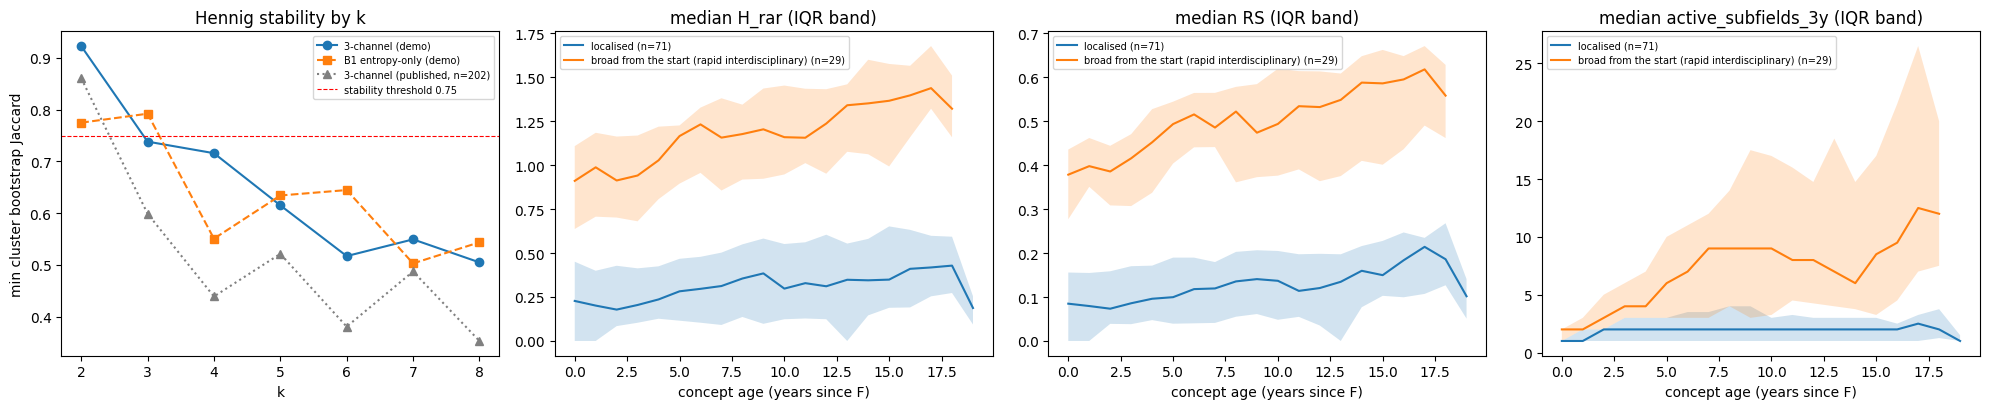

In [21]:
pub = data["full_run_reference"]
rows = [dict(metric="n MAIN concepts", demo=len(ids), published=pub["n"]),
        dict(metric="selected k (status)", demo=f"{k} ({out['status']})", published=f"{pub['k_selected']} ({pub['status']})"),
        dict(metric="min Jaccard at k=2", demo=round(out["by_k"].get("2", {}).get("min_jaccard", np.nan), 3),
             published=round(pub["min_jaccard_by_k"]["2"], 3)),
        dict(metric="cluster sizes", demo={names[int(c)]: v for c, v in out["cluster_sizes"].items()},
             published={pub["cluster_names"][c]: v for c, v in pub["cluster_sizes"].items()}),
        dict(metric="B1 selected k / min Jaccard", demo=f"{b1['k']} / {b1['min_jaccard']:.3f}",
             published=f"{pub['B1_entropy_only_MAIN']['k']} / {pub['B1_entropy_only_MAIN']['min_jaccard']:.3f}"),
        dict(metric="AMI(3ch, volume terciles)", demo=round(out["baselines"]["AMI_3ch_vs_B2_tercile"], 3),
             published=round(pub["baselines"]["AMI_3ch_vs_B2_tercile"], 3)),
        dict(metric="AMI(3ch, B1)", demo=round(out["baselines"]["AMI_3ch_vs_B1"], 3),
             published=round(pub["baselines"]["AMI_3ch_vs_B1"], 3)),
        dict(metric="p_perm cluster x origin_group", demo=round(ct["origin_group"]["p_perm"], 4),
             published=pub.get("crosstab_p_perm", {}).get("origin_group", 0.0038)),
        dict(metric="p_perm cluster x route", demo=round(ct["route"]["p_perm"], 4),
             published=pub.get("crosstab_p_perm", {}).get("route", 1.0))]
pd.set_option("display.max_colwidth", 120)
display(pd.DataFrame(rows).set_index("metric"))

# agreement with the published 3-channel labels (on the demo MAIN concepts)
cmp_ = asg.set_index("concept_id")[["cluster_name"]].join(published)
print(f"AMI(demo labels, published labels) = {ami(cmp_.cluster_name, cmp_.published_cluster_name):.3f}")
display(pd.crosstab(cmp_.cluster_name, cmp_.published_cluster_name, rownames=["demo"], colnames=["published"]))
if sens:
    display(pd.DataFrame(sens).T[["n", "min_jaccard", "AMI_vs_primary", "sizes"]])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
ax = axes[0]
kk = sorted(int(x) for x in out["by_k"])
ax.plot(kk, [out["by_k"][str(x)]["min_jaccard"] for x in kk], "o-", label="3-channel (demo)")
if b1["table"]:
    kb = sorted(int(x) for x in b1["table"])
    ax.plot(kb, [b1["table"][str(x)]["min_jaccard"] for x in kb], "s--", label="B1 entropy-only (demo)")
kp = sorted(int(x) for x in pub["min_jaccard_by_k"])
ax.plot(kp, [pub["min_jaccard_by_k"][str(x)] for x in kp], "^:", color="grey", label="3-channel (published, n=202)")
ax.axhline(JAC_MIN, color="red", lw=0.8, ls="--", label=f"stability threshold {JAC_MIN}")
ax.set_xlabel("k"); ax.set_ylabel("min cluster bootstrap Jaccard"); ax.set_title("Hennig stability by k"); ax.legend(fontsize=7)
for j, ch in enumerate(CH):
    ax = axes[j + 1]
    for c, g in traj.groupby("cluster"):
        g = g[g.n >= 3]
        ax.plot(g.age, g[f"{ch}_0.5"], label=f"{names[c]} (n={sizes[c]})")
        ax.fill_between(g.age, g[f"{ch}_0.25"], g[f"{ch}_0.75"], alpha=0.2)
    ax.set_xlabel("concept age (years since F)"); ax.set_title(f"median {ch} (IQR band)")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()